# Project Description

The goal of this project is to predict whether a borrower is likely to default on a loan using demographic, financial, and loan-related features.

The target variable is "loan_status" with it having two values:
1. 0 = loan has been paid back
2. 1 = load was defaulted

This is a Binary Classification because there are only two outcomes, namely: default vs non-default

# Imports/Dependencies

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Loading the dataset into a pandas dataframe

In [17]:
original = pd.read_csv('credit_risk_dataset.csv')
financialDF = pd.read_csv('credit_risk_dataset.csv')

# Learning the Data

In [18]:
# view the first 10 rows of the dataset
financialDF.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [19]:
# check what columns are in the dataset
list(financialDF.columns)

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [20]:
print(financialDF.shape) # (32581, 12)
financialDF.info()
financialDF.describe()

(32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


loan_status
0    25473
1     7108
Name: count, dtype: int64


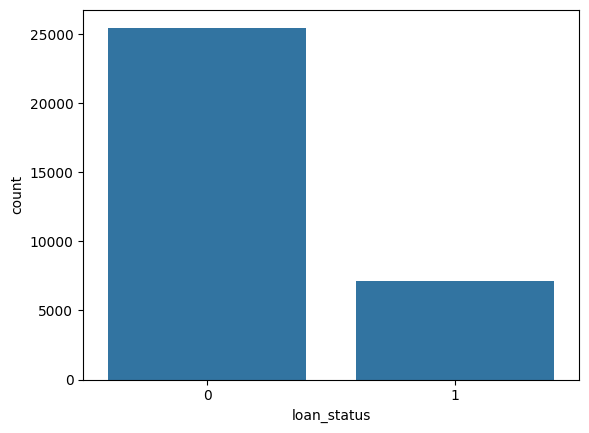

In [21]:
print(financialDF['loan_status'].value_counts())
sns.countplot(x='loan_status', data=financialDF)
plt.show()

# Data Analysis and Cleaning

1. Verifying loan status is binary (Since 0 is non default and 1 is default)

In [22]:
# check if there are any values in loan_status other than 0 and 1
for status in financialDF['loan_status']:
    if not status == 0 and not status == 1:
        print(status)

2. Removing all rows with <u>**NULL**</u> values

In [23]:
# number of empty cells per column before cleaning
print(financialDF.isnull().sum(), f"Original shape of dataframe{financialDF.shape}") # (32561,12)

# remove any row that has a missing value
financialDF.dropna(inplace=True)

# number of empty cells per column after cleaning
print(financialDF.isnull().sum(), f"Shape of updated dataframe{financialDF.shape}") # (28638, 12)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64 Original shape of dataframe(32581, 12)
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64 Shape of updated dataframe(28638, 12)


3. Removing <u>**Duplicate**</u> values

In [24]:
financialDF.drop_duplicates(inplace=True)

print(f"Shape of updated dataframe{financialDF.shape}")

Shape of updated dataframe(28501, 12)


4. Removing any <u>**outliers**</u>

In [25]:
# # remove outliers

# keep_row_mask = pd.Series([True] * len(financialDF), index=financialDF.index)

# for col in financialDF:
#     if pd.api.types.is_numeric_dtype(financialDF[col]): # returns true if a column is numeric
#         q1 = financialDF[col].quantile(0.25)
#         q3 = financialDF[col].quantile(0.75)
#         iqr = q3 - q1

#         lower = q1 - 1.5 * iqr
#         upper = q3 + 1.5 * iqr
        
        
#         keep_row_mask &= (financialDF[col] >= lower) & (financialDF[col] <= upper)

# financialDF = financialDF[keep_row_mask]

# print(len(financialDF))


In [26]:
x = financialDF.drop('loan_status', axis=1)

y = financialDF['loan_status']

x

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0.10,N,26


# Exploratory Data Analysis

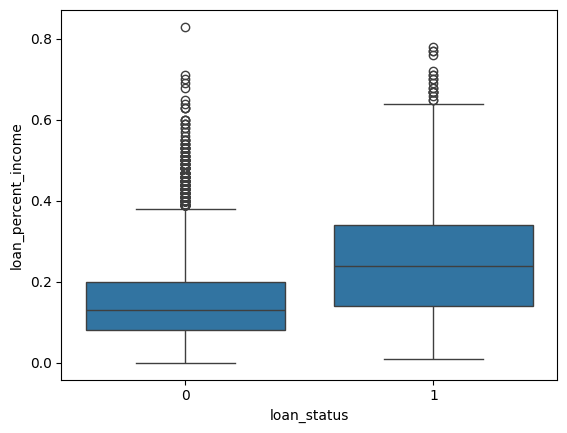

In [27]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=financialDF)
plt.show()

<Axes: xlabel='loan_grade', ylabel='count'>

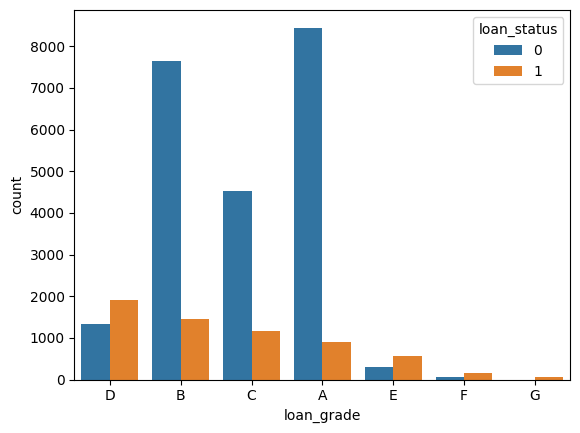

In [28]:
sns.countplot(x='loan_grade', hue='loan_status', data=financialDF)

<Axes: >

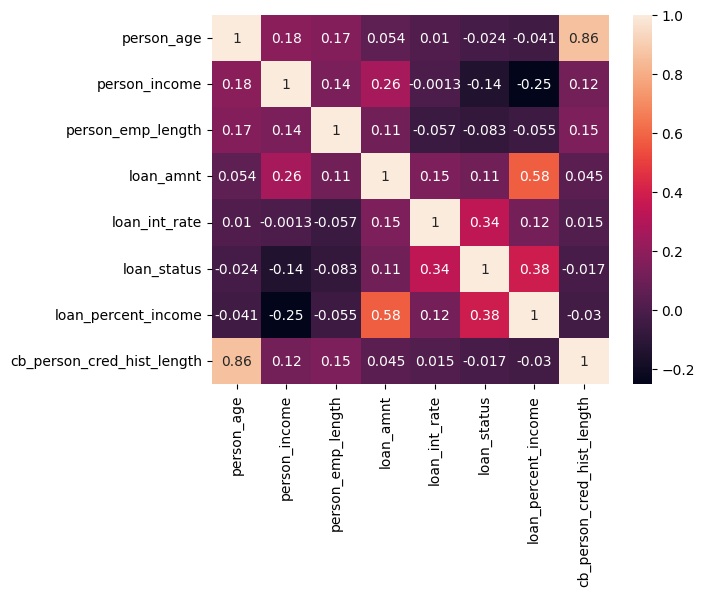

In [29]:
corr = financialDF.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

Creating a correlation heatmap of the dataset shows that for "loan_status", factors that show a strong correlation include: 
1. <u><b>loan_percent_income</b></u> (Positive Correlation): Those whose loan is a larger percent of their income are more likely to default on a loan
2. <u><b>loan_int_rate</b></u> (Positive Correlation): The higher the interest rate of a person, the more likely they are to default on their loan
3. <u><b>person_income</b></u> (Negative Correlation): The more someone makes, the less likely they are to defaulr on their loan
4. <u><b>loan_amount</b></u> (Positive Correlation): The higher the loan amount, the more likely the person is to default on the loan

# Model Training

In [30]:
# splitting the dataset


# 60/40 training/testing split
# random_state ensures reproductability
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)